In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Preprocessing
from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Simulating the dataset for notebook reproducibility
np.random.seed(42)
n_samples = 1000

data = {
    'Study_Hours': np.random.normal(5, 2, n_samples),
    'Previous_Scores': np.random.normal(70, 15, n_samples),
    'Sleep_Hours': np.random.normal(7, 1.5, n_samples),
    'Extracurricular_Activities': np.random.choice(['Yes', 'No'], n_samples),
    'Internet_Access': np.random.choice(['Yes', 'No', np.nan], n_samples, p=[0.8, 0.15, 0.05]), # 5% missing
    'Student_Motivation_Level': np.random.choice(['Low', 'Medium', 'High', np.nan], n_samples, p=[0.2, 0.5, 0.28, 0.02])
}

df = pd.DataFrame(data)
# Generating target variable 'Marks' with some logical relationships and noise
df['Marks'] = (
    10 + 
    4.5 * df['Study_Hours'] + 
    0.5 * df['Previous_Scores'] + 
    1.2 * df['Sleep_Hours'] + 
    np.random.normal(0, 5, n_samples)
)
df['Marks'] = df['Marks'].clip(0, 100) # Ensure marks are between 0 and 100

# Introduce some missing values randomly in numeric columns for realistic cleaning
df.loc[np.random.choice(df.index, 20), 'Study_Hours'] = np.nan

# Display the first 5 rows
display(df.head())

df.to_csv("Student-Marks.csv")

,Study_Hours,Previous_Scores,Sleep_Hours,Extracurricular_Activities,Internet_Access,Student_Motivation_Level,Marks
0,5.993428,90.990332,5.987233,No,Yes,High,97.294012
1,4.723471,83.869505,6.783222,No,Yes,High,80.925010
2,6.295377,70.894456,5.811370,No,No,Medium,75.707825
3,8.046060,60.295948,6.538058,No,Yes,Medium,73.771423
4,4.531693,80.473350,4.159578,Yes,Yes,Medium,68.260603


In [3]:
# Loading Dataset
data = pd.read_csv("Student-Marks.csv")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1000 non-null   int64  
 1   Study_Hours                 980 non-null    float64
 2   Previous_Scores             1000 non-null   float64
 3   Sleep_Hours                 1000 non-null   float64
 4   Extracurricular_Activities  1000 non-null   str    
 5   Internet_Access             950 non-null    str    
 6   Student_Motivation_Level    978 non-null    str    
 7   Marks                       1000 non-null   float64
dtypes: float64(4), int64(1), str(3)
memory usage: 62.6 KB


In [4]:
data.head()

,Unnamed: 0,Study_Hours,Previous_Scores,Sleep_Hours,Extracurricular_Activities,Internet_Access,Student_Motivation_Level,Marks
0,0,5.993428,90.990332,5.987233,No,Yes,High,97.294012
1,1,4.723471,83.869505,6.783222,No,Yes,High,80.925010
2,2,6.295377,70.894456,5.811370,No,No,Medium,75.707825
3,3,8.046060,60.295948,6.538058,No,Yes,Medium,73.771423
4,4,4.531693,80.473350,4.159578,Yes,Yes,Medium,68.260603


In our dataset there are two missing values in study_hours

In [6]:
data.drop(["Unnamed: 0"], axis=1, inplace=True)

In [7]:
data.head()

,Study_Hours,Previous_Scores,Sleep_Hours,Extracurricular_Activities,Internet_Access,Student_Motivation_Level,Marks
0,5.993428,90.990332,5.987233,No,Yes,High,97.294012
1,4.723471,83.869505,6.783222,No,Yes,High,80.925010
2,6.295377,70.894456,5.811370,No,No,Medium,75.707825
3,8.046060,60.295948,6.538058,No,Yes,Medium,73.771423
4,4.531693,80.473350,4.159578,Yes,Yes,Medium,68.260603


In [8]:
data.dropna(inplace=True)
data.info()

<class 'pandas.DataFrame'>
Index: 911 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Study_Hours                 911 non-null    float64
 1   Previous_Scores             911 non-null    float64
 2   Sleep_Hours                 911 non-null    float64
 3   Extracurricular_Activities  911 non-null    str    
 4   Internet_Access             911 non-null    str    
 5   Student_Motivation_Level    911 non-null    str    
 6   Marks                       911 non-null    float64
dtypes: float64(4), str(3)
memory usage: 56.9 KB


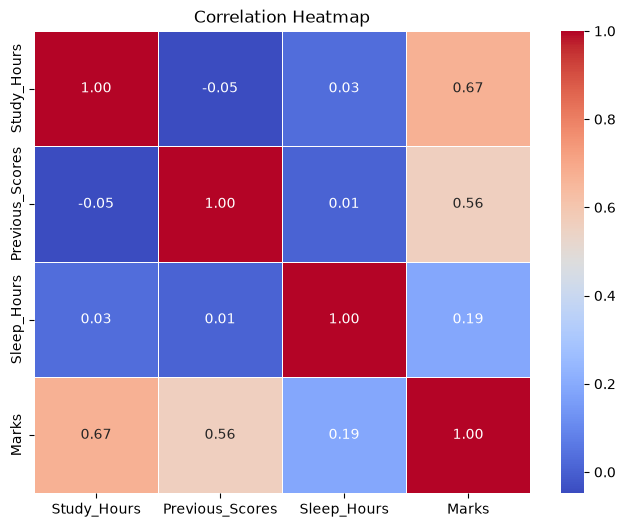

In [9]:
plt.figure(figsize=(8, 6))
numeric_cols = data.select_dtypes(include=[np.number]).columns
correlation_matrix = data[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [10]:
data.describe()

,Study_Hours,Previous_Scores,Sleep_Hours,Marks
count,911.000000,911.000000,911.000000,911.000000
mean,5.072926,71.070929,7.004403,76.306765
std,1.961140,14.694492,1.482905,12.038866
min,-1.482535,25.894170,2.470732,35.300719
25%,3.775694,60.915022,6.033228,68.355810
50%,5.091144,70.894456,6.979243,75.905484
75%,6.320675,80.623887,7.993877,84.371324
max,12.705463,117.896614,12.889357,100.000000


### Data Cleaning and Preprocessing

In [14]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')

# SimpleImputer(strategy='median')
# SimpleImputer(strategy='most_frequent')
# SimpleImputer(strategy='constant', fill_value=0)


# cat_imputer = SimpleImputer(strategy='most_frequent')
# cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

In [11]:
numeric_features = ['Study_Hours', 'Previous_Scores', 'Sleep_Hours']
nominal_features = ['Extracurricular_Activities', 'Internet_Access']
ordinal_features = ['Student_Motivation_Level']

In [12]:
# from sklearn.impute import SimpleImputer

# num_imputer = SimpleImputer(strategy='mean')

# X_num = pd.DataFrame(
#     num_imputer.fit_transform(X_num),
#     columns=numerical_features
# )


# cat_imputer = SimpleImputer(strategy='most_frequent')

# X_cat = pd.DataFrame(
#     cat_imputer.fit_transform(X_cat),
#     columns=nominal_features
# )

#####  Nominal Data Encoding

In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_cat_encoded = encoder.fit_transform(data[nominal_features])

encoded_columns = encoder.get_feature_names_out(nominal_features)

X_cat_encoded = pd.DataFrame(
    X_cat_encoded,
    columns=encoded_columns
)

X_cat_encoded

,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes
0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,1.0
2,1.0,0.0,1.0,0.0
3,1.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0
...,...,...,...,...
906,0.0,1.0,0.0,1.0
907,0.0,1.0,0.0,1.0
908,0.0,1.0,0.0,1.0
909,1.0,0.0,0.0,1.0


##### Ordinal Data Encoding

In [24]:
from sklearn.preprocessing import OrdinalEncoder

ord_encoder = OrdinalEncoder()

X_cat_ord_encoded = pd.DataFrame(
    ord_encoder.fit_transform(data[ordinal_features]),
    columns=ordinal_features
)

X_cat_ord_encoded

,Student_Motivation_Level
0,0.0
1,0.0
2,2.0
3,2.0
4,2.0
...,...
906,1.0
907,0.0
908,2.0
909,0.0


##### Feature Scaling

In [25]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()

# X_num_scaled = pd.DataFrame(
#     scaler.fit_transform(X_num),
#     columns=numerical_cols
# )

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_num_scaled = pd.DataFrame(
    scaler.fit_transform(data[numeric_features]),
    columns=numeric_features
)

X_num_scaled

,Study_Hours,Previous_Scores,Sleep_Hours
0,0.469629,1.356314,-0.686308
1,-0.178287,0.871456,-0.149236
2,0.623680,-0.012016,-0.804966
3,1.516856,-0.733669,-0.314654
4,-0.276130,0.640212,-1.919468
...,...,...,...
906,-0.324034,1.020080,0.075446
907,1.797109,-0.100007,0.257896
908,0.616694,-0.973624,-1.259737
909,-0.620023,-0.239468,0.335243


In [28]:
data.head()
y = data["Marks"]

# from sklearn.preprocessing import StandardScaler

# y_scaler = StandardScaler()

# y_scaled = y_scaler.fit_transform(
#     np.array(y).reshape(-1, 1)
# )
y

0      97.294012
1      80.925010
2      75.707825
3      73.771423
4      68.260603
         ...    
995    82.165196
996    96.599844
997    78.937636
998    71.827682
999    72.225805
Name: Marks, Length: 911, dtype: float64

In [26]:
X_final = pd.concat(
    [X_num_scaled, X_cat_encoded, X_cat_ord_encoded],
    axis=1
)

X_final

,Study_Hours,Previous_Scores,Sleep_Hours,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_No,Internet_Access_Yes,Student_Motivation_Level
0,0.469629,1.356314,-0.686308,1.0,0.0,0.0,1.0,0.0
1,-0.178287,0.871456,-0.149236,1.0,0.0,0.0,1.0,0.0
2,0.623680,-0.012016,-0.804966,1.0,0.0,1.0,0.0,2.0
3,1.516856,-0.733669,-0.314654,1.0,0.0,0.0,1.0,2.0
4,-0.276130,0.640212,-1.919468,0.0,1.0,0.0,1.0,2.0
...,...,...,...,...,...,...,...,...
906,-0.324034,1.020080,0.075446,0.0,1.0,0.0,1.0,1.0
907,1.797109,-0.100007,0.257896,0.0,1.0,0.0,1.0,0.0
908,0.616694,-0.973624,-1.259737,0.0,1.0,0.0,1.0,2.0
909,-0.620023,-0.239468,0.335243,1.0,0.0,0.0,1.0,0.0


### Data Splitting

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
print(f"Testing data shape: X={X_test.shape}, y={y_test.shape}")

Training data shape: X=(728, 8), y=(728,)
Testing data shape: X=(183, 8), y=(183,)


### Model Training

In [30]:
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [31]:
print(model.coef_)
print(model.intercept_)

[ 8.23240945  7.12715114  2.04417347  0.1143636  -0.1143636   0.05212388
 -0.05212388  0.1094644 ]
76.20559171510352


In [33]:
# Predict on test data
y_pred = model.predict(X_test)

# Display first 5 predictions against actual values
results_df = pd.DataFrame({'Actual Marks': y_test, 'Predicted Marks': y_pred})
# display(results_df.head())
results_df

,Actual Marks,Predicted Marks
773,75.996664,81.927534
835,80.863234,79.414367
600,77.949449,76.690320
402,78.374849,82.979917
394,82.673657,82.501510
...,...,...
374,100.000000,106.762620
642,76.633657,70.921765
981,71.799145,71.703559
493,68.390634,72.530943


In [35]:
model.score(X_test, y_test)

0.8398200583596125

### Model Evaluation

In [36]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Evaluation Metrics ---")
print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f} ({r2*100:.2f}%)")

--- Model Evaluation Metrics ---
MAE:  3.84
MSE:  23.41
RMSE: 4.84
R²:   0.8398 (83.98%)


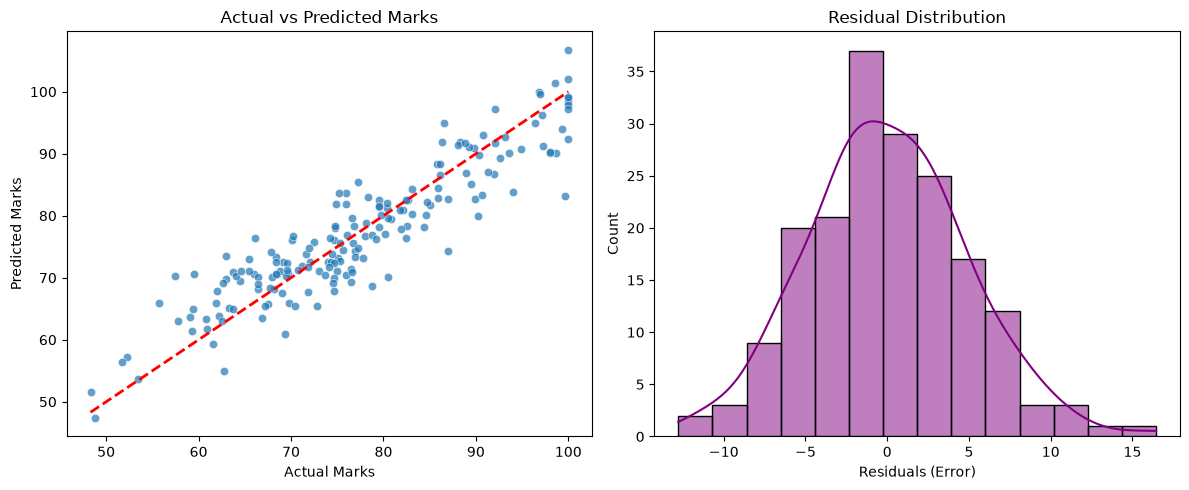

In [37]:
# Visualization: Actual vs Predicted
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Marks')
plt.ylabel('Predicted Marks')
plt.title('Actual vs Predicted Marks')

# Visualization: Residual Analysis
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.xlabel('Residuals (Error)')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()